   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           No

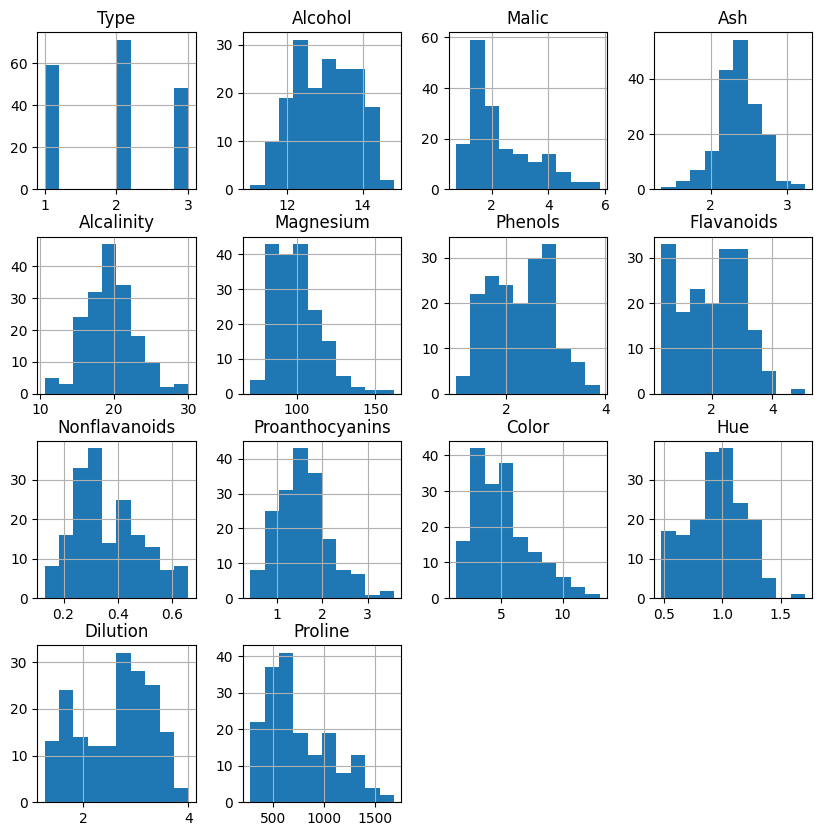

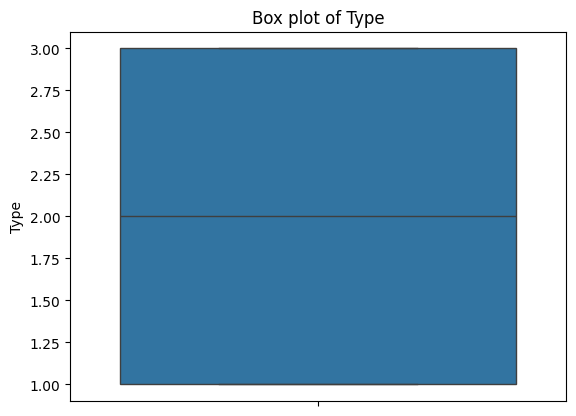

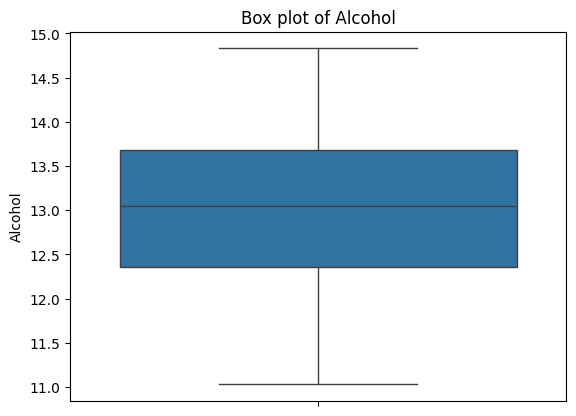

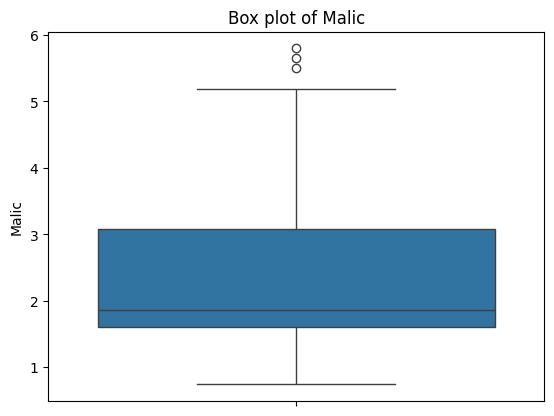

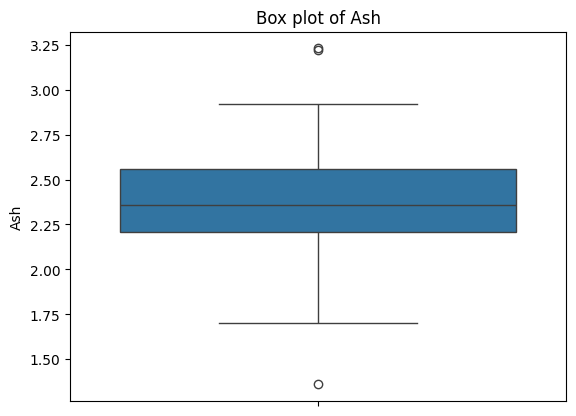

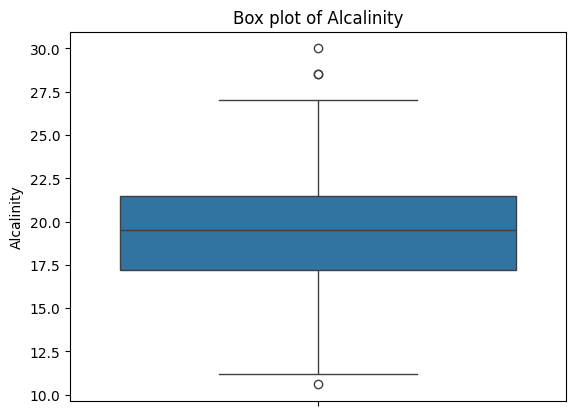

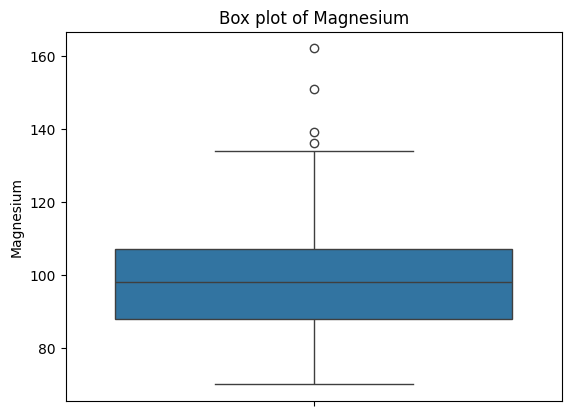

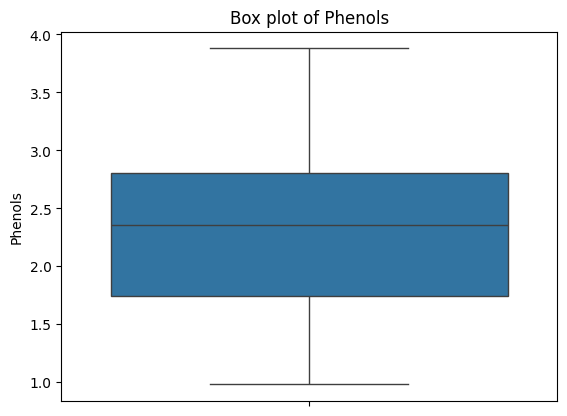

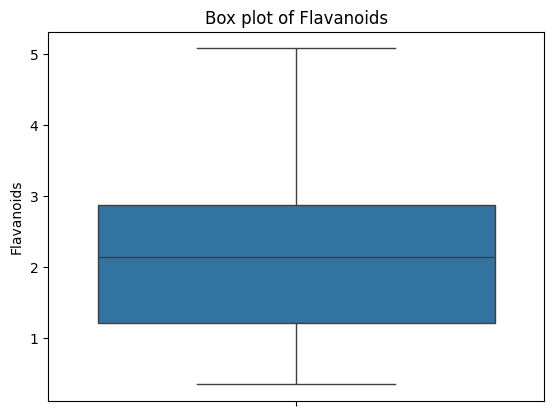

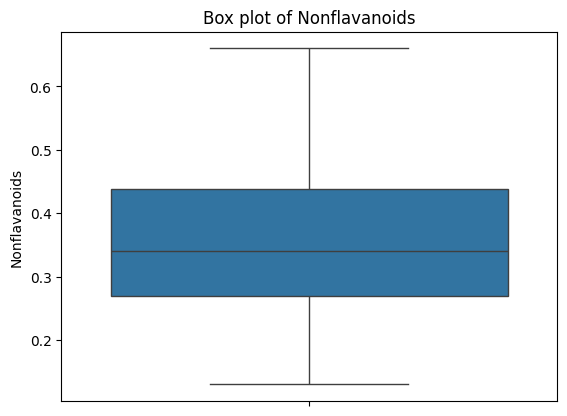

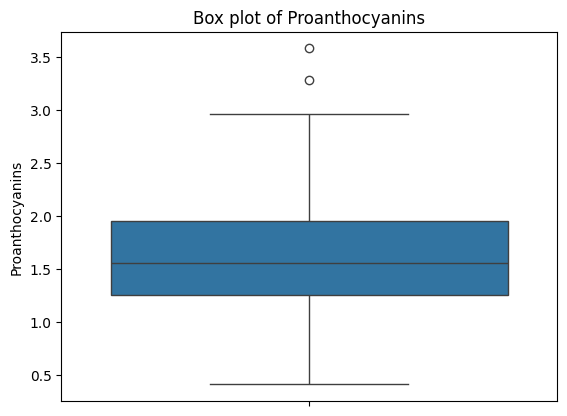

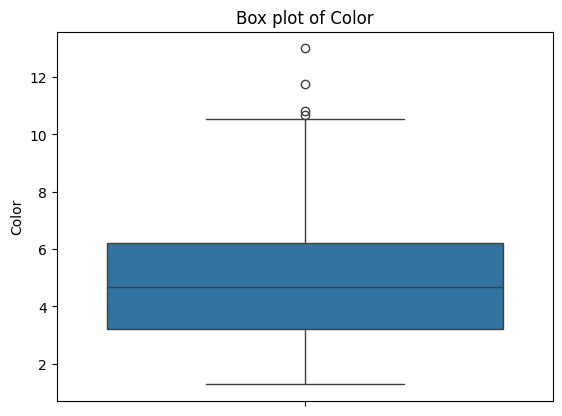

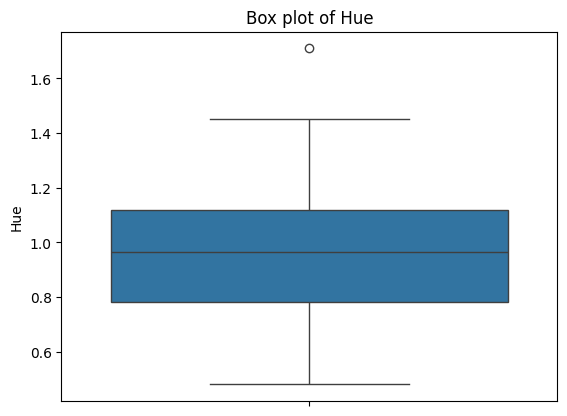

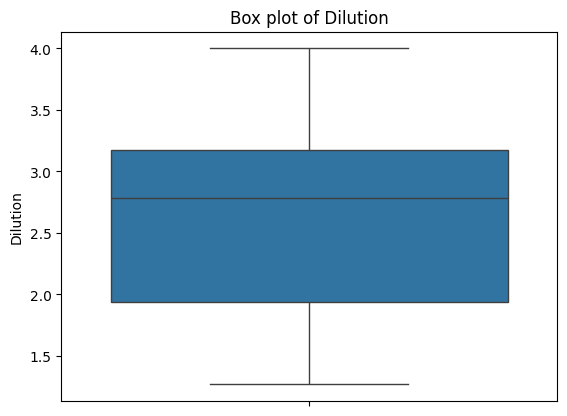

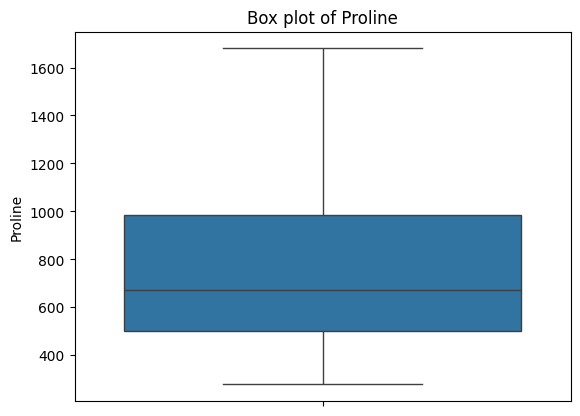

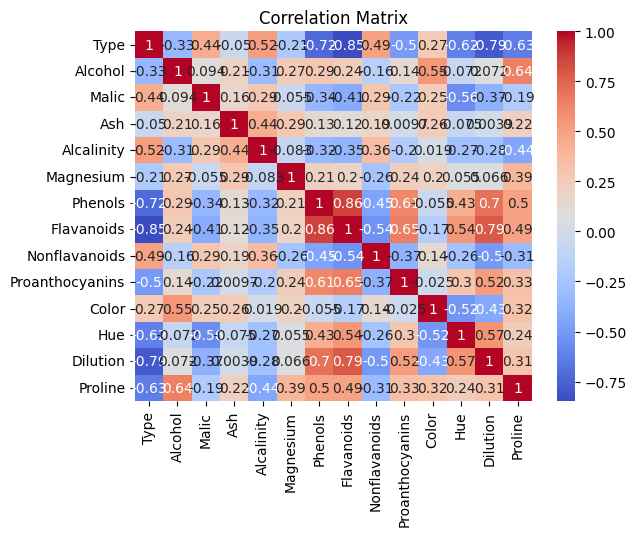

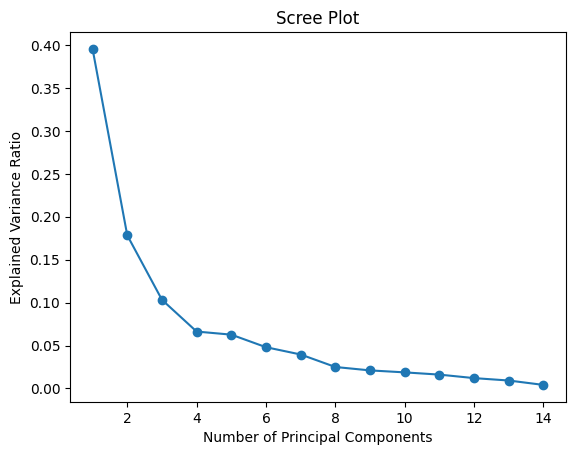

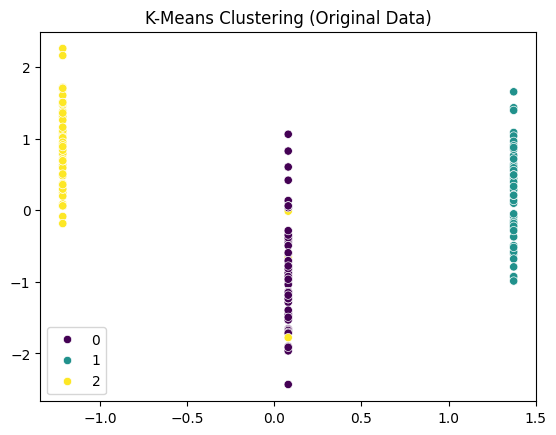

K-Means Silhouette Score (Original Data): 0.30648398324833453


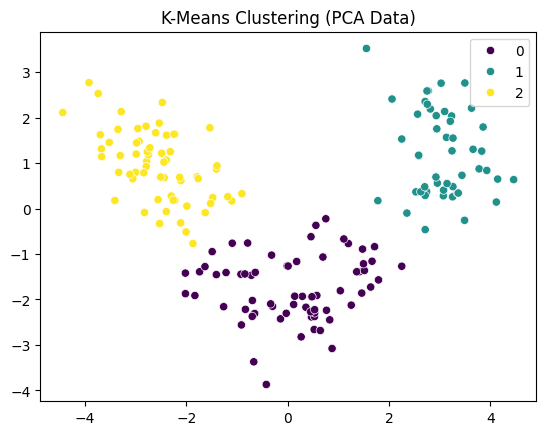

K-Means Silhouette Score (PCA Data): 0.48817506649357845
Original Data Silhouette Score: 0.30648398324833453
PCA Data Silhouette Score: 0.48817506649357845
Key Findings and Insights:


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the dataset
df = pd.read_csv('wine.csv')

# Task 1: Exploratory Data Analysis (EDA)

# Basic data exploration
print(df.head())
print(df.info())
print(df.describe())

# Examine the distribution of features
df.hist(figsize=(10, 10))
plt.show()

for column in df.select_dtypes(include=['number']).columns:
    sns.boxplot(df[column])
    plt.title(f'Box plot of {column}')
    plt.show()

# Correlation matrix
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Task 2: Dimensionality Reduction with PCA

# Standardize the features
numeric_cols = df.select_dtypes(include=['number']).columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# Implement PCA
pca = PCA()
pca.fit(scaled_data)
explained_variance = pca.explained_variance_ratio_

# Scree Plot
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

# Transform the original dataset into principal components
pca = PCA(n_components=3)  # Replace 3 with the optimal number of components
pca_data = pca.fit_transform(scaled_data)

# Task 3: Clustering with Original Data

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)  # Example with 3 clusters
kmeans_labels = kmeans.fit_predict(scaled_data)

# Visualize the clustering results
sns.scatterplot(x=scaled_data[:, 0], y=scaled_data[:, 1], hue=kmeans_labels, palette='viridis')
plt.title('K-Means Clustering (Original Data)')
plt.show()

# Evaluate clustering performance
kmeans_silhouette = silhouette_score(scaled_data, kmeans_labels)
print(f'K-Means Silhouette Score (Original Data): {kmeans_silhouette}')

# Task 4: Clustering with PCA Data

# Apply K-Means to PCA-transformed data
kmeans_pca = KMeans(n_clusters=3, random_state=42)  # Example with 3 clusters
kmeans_pca_labels = kmeans_pca.fit_predict(pca_data)

# Visualize clustering results with PCA data
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=kmeans_pca_labels, palette='viridis')
plt.title('K-Means Clustering (PCA Data)')
plt.show()

# Evaluate clustering performance with PCA data
kmeans_pca_silhouette = silhouette_score(pca_data, kmeans_pca_labels)
print(f'K-Means Silhouette Score (PCA Data): {kmeans_pca_silhouette}')

# Task 5: Comparison and Analysis

# Compare the clustering results
print(f'Original Data Silhouette Score: {kmeans_silhouette}')
print(f'PCA Data Silhouette Score: {kmeans_pca_silhouette}')

# Additional analysis based on your observations

# Task 6: Conclusion and Insights

# Summarize findings and practical implications
print("Key Findings and Insights:")
# Add your analysis here
